In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import backtestPairs, calculatePairMetrics
# from MODELS.teamInfo import *


In [2]:
import joblib

# Load NGBoost mean and variance models
mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_BACKTEST.pkl')
variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_BACKTEST.pkl')
calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_BACKTEST.pkl')


models = {
    'mean': mean_model,
    'variance': variance_model,
    'calibration_factor': calibration_factor,
}

features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

print(f"Loaded NGBoost models with calibration factor: {calibration_factor}")
print(f"Number of features: {len(features)}")

Loaded NGBoost models with calibration factor: 4.5
Number of features: 170


In [3]:
pd.set_option('display.max_columns', None)

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
# s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'underdog') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)


/var/folders/9q/5_554qsx5z70w9d_vkmvjg0h0000gn/T/ipykernel_84104/1633982547.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
27176,27176,27176,27176,Julius Randle,player_points,underdog,over,19.5,-137,San Antonio Spurs,Minnesota Timberwolves,e45d417f345d21a702da9414af2aee73,2024-12-16T00:10:00Z,2024-12-15,NaN,NaN,NaN,over
130433,130433,130433,33260,Nickeil Alexander-Walker,player_points,underdog,over,7.5,-137,Denver Nuggets,Minnesota Timberwolves,NaN,NaN,2025-03-13,game,7.5,104.0,over
73068,73068,73068,73068,Gary Trent Jr,player_points,underdog,over,9.5,-137,Milwaukee Bucks,Philadelphia 76ers,NaN,NaN,2025-02-09,game,11.5,100.0,over
177318,177318,177318,93461,Toumani Camara,player_points,underdog,under,13.5,-137,Toronto Raptors,Portland Trail Blazers,NaN,NaN,2025-04-03,game,11.5,-111.0,under
141936,141936,141936,47775,DeAndre Jordan,player_points,underdog,over,5.5,-137,Golden State Warriors,Denver Nuggets,NaN,NaN,2025-03-18,game,5.5,100.0,over


In [5]:
# backtestData= pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/s26props.csv')

# backtestData = backtestData[(backtestData['BOOKMAKER'] == 'Underdog') &  
#                             (backtestData['CATEGORY'] == 'player_points')]
# backtestData.rename(columns={'COMMENCE_TIME': 'GAME_DATE', 'OVER/UNDER': 'SIDE'}, inplace=True)
# backtestData

In [5]:
date = '2024-11-25'

results = backtestPairs(s25, backtestData, date, models, features, edge_threshold=4, top_n=10, 
                 stat_col='PTS', stake=10, max_player_appearances = 1)


# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("PAIR BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['pair_profit'].sum() * 3
    avg_profit = results['pair_profit'].mean() * 3
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

Starting backtest for pairs on 2024-11-25
Pre-computing predictions for 77 players...
Error getting prediction for Brandon Ingram: No data found for player Brandon Ingram
Error getting prediction for C.J. McCollum: No data found for player C.J. McCollum
Error getting prediction for Jalen Suggs: No data found for player Jalen Suggs
Error getting prediction for Wendell Carter Jr: No data found for player Wendell Carter Jr
Error getting prediction for Moussa Diabate: No data found for player Moussa Diabate
Error getting prediction for Tim Hardaway Jr: No data found for player Tim Hardaway Jr
Error getting prediction for Ron Holland: No data found for player Ron Holland
Error getting prediction for R.J. Barrett: No data found for player R.J. Barrett
Error getting prediction for Derrick Jones: No data found for player Derrick Jones
Error getting prediction for Klay Thompson: No data found for player Klay Thompson
Error getting prediction for Jaren Jackson Jr: No data found for player Jaren 

,NAME 1,NAME 2,LINE 1,LINE 2,PREDICTION 1,PREDICTION 2,MODEL SIDE 1,MODEL SIDE 2,PROB 1,PROB 2,PROB BOTH,EDGE 1,EDGE 2,COMBINED EDGE,EV$,KELLY FULL,RECOMMENDATION,CI 1,CI 2,INTERVAL WIDTH 1,INTERVAL WIDTH 2,SIGMA 1,SIGMA 2,SIGMA FLAG 1,SIGMA FLAG 2,CORRELATION,SAME_GAME,EXPECTED ROI,actual1,actual2,leg1_won,leg2_won,pair_won,pair_recommendation,pair_profit,selection,date
0,Franz Wagner,James Harden,28.5,23.5,21.74,18.17,under,under,0.859,0.785,0.6616,0.281,0.207,0.341,9.85,0.492,1,"(9.4, 34.0)","(5.0, 31.4)",None,None,6.27,6.74,High,High,0.05,0,98.5,21,19,1,1,1,1,20.0,top_ev,2024-11-25
1,Josh Green,Anfernee Simons,8.5,19.5,5.38,14.05,under,under,0.742,0.785,0.5705,0.164,0.207,0.248,7.11,0.356,0,"(0.0, 14.8)","(0.5, 27.6)",None,None,4.81,6.92,Low,High,0.05,0,71.1,2,5,1,1,1,0,20.0,top_ev,2024-11-25
2,Brandon Miller,Trayce Jackson-Davis,21.5,8.5,18.04,12.15,under,over,0.724,0.736,0.5222,0.146,0.158,0.199,5.67,0.283,0,"(6.6, 29.4)","(0.8, 23.5)",None,None,5.82,5.79,Med,Med,0.05,0,56.7,20,8,1,0,0,0,-10.0,top_ev,2024-11-25
3,Quenton Jackson,Dyson Daniels,6.5,11.5,9.96,15.21,over,over,0.717,0.702,0.4939,0.139,0.124,0.170,4.82,0.241,0,"(0.0, 21.7)","(1.5, 28.9)",None,None,6.01,6.98,High,High,0.05,0,48.2,12,17,1,1,1,0,20.0,top_ev,2024-11-25
4,Zaccharie Risacher,Shaedon Sharpe,9.5,19.5,13.21,16.15,over,under,0.698,0.698,0.4775,0.120,0.120,0.153,4.33,0.216,0,"(0.0, 27.2)","(3.5, 28.8)",None,None,7.14,6.47,High,High,0.05,0,43.3,5,15,0,1,0,0,-10.0,top_ev,2024-11-25
5,Trey Murphy III,Jerami Grant,17.5,15.5,21.20,12.56,over,under,0.698,0.682,0.4663,0.120,0.104,0.142,3.99,0.200,0,"(7.2, 35.2)","(0.4, 24.7)",None,None,7.14,6.21,High,High,0.05,0,39.9,24,11,1,1,1,0,20.0,top_ev,2024-11-25
6,Scottie Barnes,Kevin Porter Jr.,19.5,11.5,16.45,8.97,under,under,0.681,0.675,0.4502,0.103,0.097,0.125,3.51,0.175,0,"(3.8, 29.2)","(0.0, 19.9)",None,None,6.48,5.58,High,Med,0.05,0,35.1,31,7,0,1,0,0,-10.0,top_ev,2024-11-25
7,Jrue Holiday,Nikola Jokić,10.5,28.5,12.84,31.21,over,over,0.646,0.660,0.4175,0.068,0.082,0.092,2.52,0.126,0,"(0.6, 25.1)","(18.3, 44.1)",None,None,6.26,6.58,High,High,0.05,0,25.2,5,22,0,0,0,0,-10.0,top_ev,2024-11-25
8,Kevin Huerter,Lindy Waters III,9.5,7.5,7.08,9.62,under,over,0.644,0.639,0.4035,0.066,0.061,0.078,2.11,0.105,0,"(0.0, 19.9)","(0.0, 21.3)",None,None,6.53,5.97,High,Med,0.05,0,21.1,0,13,1,1,1,0,20.0,top_ev,2024-11-25
9,Jaden Ivey,Kyrie Irving,20.5,26.5,18.06,23.93,under,under,0.638,0.638,0.3989,0.060,0.060,0.073,1.97,0.098,0,"(4.5, 31.6)","(9.7, 38.2)",None,None,6.92,7.27,High,High,0.05,0,19.7,25,32,0,0,0,0,-10.0,top_ev,2024-11-25


## Points

In [10]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(s25, backtestData, date, models, features, edge_threshold=3.5, top_n=10, 
                 stat_col='PTS', stake=10, max_player_appearances = 1)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-22... 1/163
Starting backtest for pairs on 2024-10-22
Pre-computing predictions for 29 players...
Processing 29 players...
Generated 314 valid 2-leg combinations
Time taken for pairs: 0.14706110954284668 seconds
Time taken for sorting: 0.14720702171325684 seconds
Time taken for dropping duplicates: 0.14800524711608887 seconds
Time taken for iterating over evData: 0.14801502227783203 seconds
Time taken for backtest_results: 0.14983916282653809 seconds
  ✓ Processed 10 bets
Processing 2024-10-23... 2/163
Starting backtest for pairs on 2024-10-23
Pre-computing predictions for 110 players...
Error getting prediction for Nicolas Claxton: No data found for player Nicolas Claxton
Error getting prediction for Jimmy Butler: No data found for player Jimmy Butler
Error getting prediction for Jaime Jaquez Jr: No data found for player Jaime Jaquez Jr
Error getting prediction for Wendell Carter Jr: No data found for player Wendell Carter Jr
Error getting prediction for Jabari Smit

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,312
   Wins: 479
   Hit Rate: 36.51%
   Total Profit: $1,250.00
   Total Staked: $13,120.00
   ROI: 9.53%
   Volatility: $39.98
   Max Drawdown: $-280.00
   Sharpe Ratio: 4.392

   PROBABILITY METRICS:
   Brier Score: 0.2418 (lower is better)
   Log Loss: 0.6789 (lower is better)
   AUC-ROC: 0.5865 (higher is better)
   Samples: 1312

 RECOMMENDED BETS ANALYSIS (Edge > 0.60):
   Total Bets: 380
   Wins: 180
   Hit Rate: 47.37%
   Total Profit: $1,600.00
   Total Staked: $3,800.00
   ROI: 42.11%
   Volatility: $27.50
   Max Drawdown: $-70.00
   Sharpe Ratio: 9.419


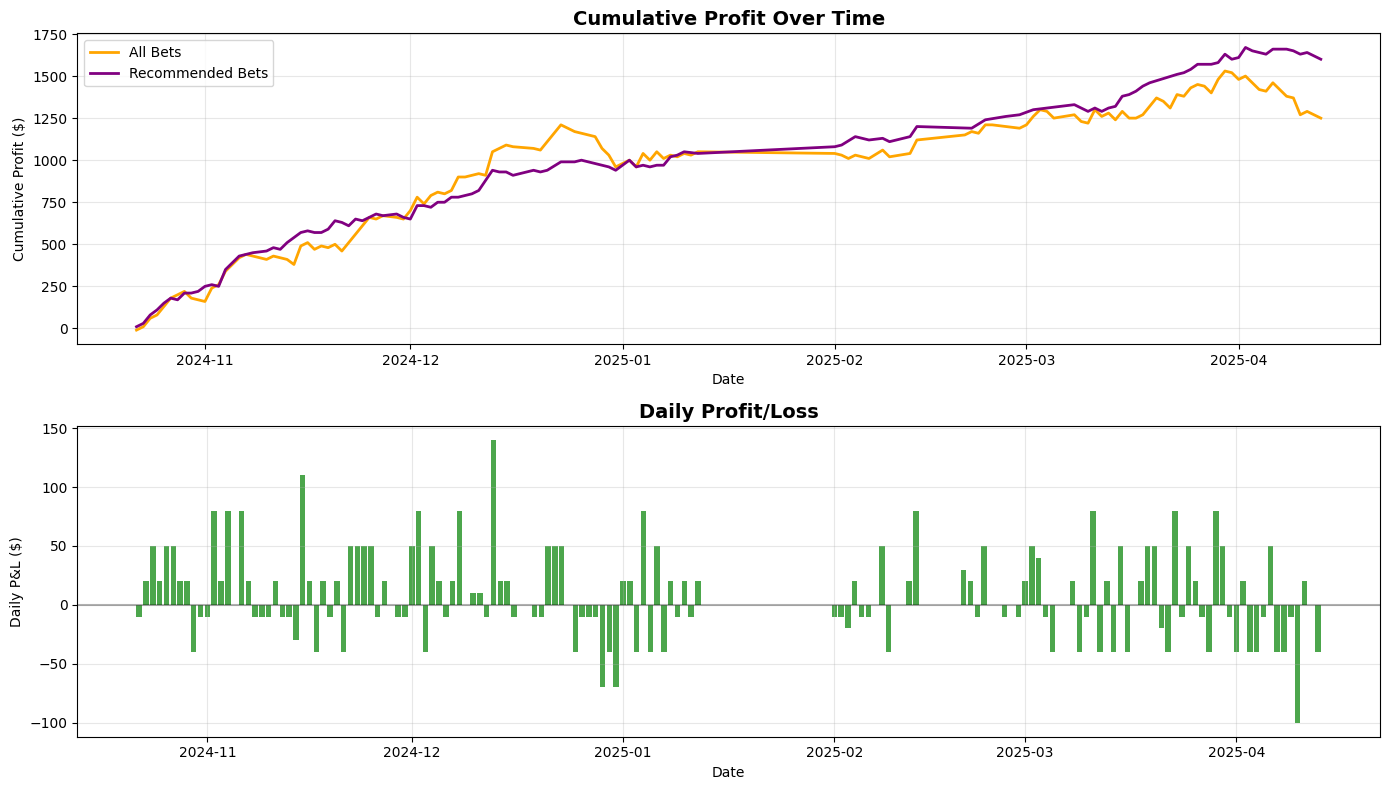

In [ ]:
all_metrics = calculatePairMetrics(final_results, stake=10)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=10)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics
    if 'probability_metrics' in all_metrics and 'error' not in all_metrics['probability_metrics']:
        prob_metrics = all_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

if rec_metrics:
    print("\n RECOMMENDED BETS ANALYSIS (Edge > 3.5):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")
    
# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()